# Модуль 9. Свёртки и представления

Ноутбук к [модулю 9](https://drobyshevdev.github.io/lemma/modules/09-convolutions/).

Свёртка, пулинг и обратный проход через них пишутся с нуля. Данные генерируются здесь же — три класса простых фигур 16×16, поэтому всё считается на CPU за десятки секунд и никаких загрузок не требуется.

Главный сюжет в конце: сдвиг изображения на два пикселя. Полносвязная сеть его не переживает, свёрточная не замечает.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["axes.grid"] = False

SIZE = 16
CLASSES = ["горизонталь", "вертикаль", "крест"]

## 0. Данные

Три класса: горизонтальная полоса, вертикальная, крест. Положение и толщина случайны — значит модели придётся выучить *что* нарисовано, а не *где*.

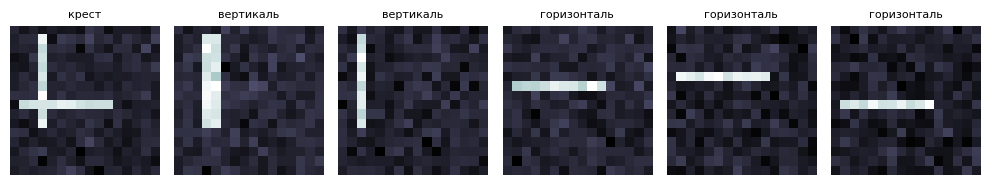

классы в обучении: [473 503 524]


In [2]:
def shift_image(img, s):
    """Сдвиг с заполнением нулями, а не по кругу: np.roll перенёс бы уехавший
    край на другую сторону и превратил полосу в две."""
    if s == 0:
        return img
    out = np.zeros_like(img)
    out[s:, s:] = img[:-s or None, :-s or None]
    return out

def make_images(n, seed=0, shift=0):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, SIZE, SIZE))
    y = rng.integers(0, 3, n)
    for i in range(n):
        img = np.zeros((SIZE, SIZE))
        r = int(rng.integers(2, SIZE - 6))
        c = int(rng.integers(2, SIZE - 6))
        w = int(rng.integers(1, 3))
        if y[i] in (0, 2):
            img[r:r + w, 1:SIZE - 5] = 1.0
        if y[i] in (1, 2):
            img[1:SIZE - 5, c:c + w] = 1.0
        X[i] = shift_image(img, shift) + rng.normal(0, 0.08, (SIZE, SIZE))
    return X, y

X_train, y_train = make_images(1500, seed=0)
X_test, y_test = make_images(600, seed=99)

fig, axes = plt.subplots(1, 6, figsize=(10, 1.9))
for ax, i in zip(axes, range(6)):
    ax.imshow(X_train[i], cmap="bone")
    ax.set_title(CLASSES[y_train[i]], fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()
print("классы в обучении:", np.bincount(y_train))

## 1. Свёртка руками

Проверяем реализацию на известном ответе: оператор Собеля обязан подсветить вертикальные границы.

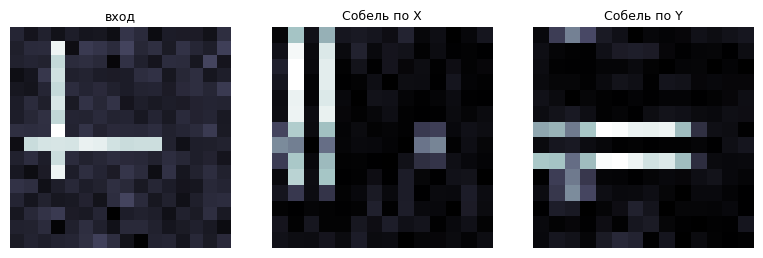

Реализация верна: одно ядро нашло вертикальные границы, другое горизонтальные,
хотя ни одно из них ничему не обучалось.


In [3]:
def im2col(X, k):
    """Каждое окно k*k превращается в строку. Свёртка становится умножением матриц."""
    n, h, w = X.shape
    oh, ow = h - k + 1, w - k + 1
    cols = np.empty((n, oh, ow, k * k))
    for i in range(k):
        for j in range(k):
            cols[:, :, :, i * k + j] = X[:, i:i + oh, j:j + ow]
    return cols.reshape(n * oh * ow, k * k), oh, ow

def conv(X, kernels):
    """kernels: (F, k, k). Возвращает (N, F, oh, ow)."""
    f, k, _ = kernels.shape
    cols, oh, ow = im2col(X, k)
    out = cols @ kernels.reshape(f, -1).T
    return out.reshape(len(X), oh, ow, f).transpose(0, 3, 1, 2)

sobel_x = np.array([[[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]]])
sobel_y = sobel_x.transpose(0, 2, 1)

sample = X_train[y_train == 2][0]                  # крест: есть обе границы
gx = conv(sample[None], sobel_x)[0, 0]
gy = conv(sample[None], sobel_y)[0, 0]

fig, axes = plt.subplots(1, 3, figsize=(8, 2.6))
for ax, img, title in [(axes[0], sample, "вход"),
                       (axes[1], np.abs(gx), "Собель по X"),
                       (axes[2], np.abs(gy), "Собель по Y")]:
    ax.imshow(img, cmap="bone"); ax.set_title(title, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

print("Реализация верна: одно ядро нашло вертикальные границы, другое горизонтальные,")
print("хотя ни одно из них ничему не обучалось.")

## 2. Сколько параметров

Тот же вход, два способа обработать первый слой.

In [4]:
print(f"{'размер картинки':>18} {'полносвязный (128)':>21} {'свёрточный (8 ядер 3x3)':>26}")
for n in [16, 28, 64, 256, 1024]:
    dense = n * n * 128 + 128
    convp = 3 * 3 * 1 * 8 + 8
    print(f"{f'{n}x{n}':>18} {dense:>21,} {convp:>26,}")
print("\nУ свёрточного слоя число параметров вообще не зависит от размера входа.")

   размер картинки    полносвязный (128)    свёрточный (8 ядер 3x3)
             16x16                32,896                         80
             28x28               100,480                         80
             64x64               524,416                         80
           256x256             8,388,736                         80
         1024x1024           134,217,856                         80

У свёрточного слоя число параметров вообще не зависит от размера входа.


## 3. Свёрточная сеть с нуля

Свёртка → ReLU → **глобальный** max-pooling → линейный слой → softmax.

Пулинг берёт максимум по всей карте сразу, а не окнами 2×2. От каждого ядра остаётся одно число: сработало или нет, безразлично где. Это и есть превращение эквивариантности в инвариантность, и без него сеть сдвиг не переживает — проверьте сами, заменив глобальный максимум на окна.

Свёртка стоит первым слоем, поэтому градиент под неё пробрасывать не нужно: достаточно градиента по её весам. Это упрощает код и ничего не упрощает в понимании.

In [5]:
K, F = 3, 8

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy(p, y):
    return float(-np.mean(np.log(np.clip(p[np.arange(len(y)), y], 1e-12, None))))

def init_cnn(seed=0):
    rng = np.random.default_rng(seed)
    return {
        "kernels": rng.normal(0, np.sqrt(2.0 / (K * K)), (F, K, K)),
        "kb": np.zeros(F),
        "W": rng.normal(0, np.sqrt(2.0 / F), (F, 3)),
        "b": np.zeros(3),
    }

def cnn_forward(p, X):
    """Свёртка -> ReLU -> ГЛОБАЛЬНЫЙ max-pool -> линейный слой.

    Пулинг по всей карте, а не окнами 2x2. Это и есть разница между
    эквивариантностью и инвариантностью: признак, найденный где угодно,
    даёт один и тот же выход.
    """
    cols, oh, ow = im2col(X, K)
    z = cols @ p["kernels"].reshape(F, -1).T + p["kb"]
    conv_out = z.reshape(len(X), oh * ow, F)
    a = np.maximum(0.0, conv_out)
    idx = a.argmax(axis=1)                       # где сработало каждое ядро
    pooled = a.max(axis=1)                       # (N, F): только факт срабатывания
    logits = pooled @ p["W"] + p["b"]
    return softmax(logits), dict(cols=cols, oh=oh, ow=ow,
                                 conv_out=conv_out, idx=idx, pooled=pooled)

def cnn_backward(p, cache, probs, y):
    n = len(y)
    dlogits = probs.copy()
    dlogits[np.arange(n), y] -= 1.0              # softmax + CE дают p - y
    dlogits /= n

    gW = cache["pooled"].T @ dlogits
    gb = dlogits.sum(axis=0)

    dpooled = dlogits @ p["W"].T                 # (N, F)
    # Градиент идёт только в ту позицию, где был максимум.
    dconv = np.zeros_like(cache["conv_out"])
    rows = np.arange(n)[:, None]
    chans = np.arange(F)[None, :]
    dconv[rows, cache["idx"], chans] = dpooled * (cache["pooled"] > 0)

    dz_flat = dconv.reshape(-1, F)
    gk = (cache["cols"].T @ dz_flat).T.reshape(F, K, K)
    gkb = dz_flat.sum(axis=0)
    return {"kernels": gk, "kb": gkb, "W": gW, "b": gb}

In [6]:
def gradient_check_cnn(p, X, y, h=1e-5):
    probs, cache = cnn_forward(p, X)
    grads = cnn_backward(p, cache, probs, y)
    worst = {}
    rng = np.random.default_rng(0)
    for name in ["kernels", "W", "kb", "b"]:
        arr = p[name]
        flat = arr.ravel()
        picks = rng.choice(len(flat), min(12, len(flat)), replace=False)
        errs = []
        for idx in picks:
            old = flat[idx]
            flat[idx] = old + h
            plus = cross_entropy(cnn_forward(p, X)[0], y)
            flat[idx] = old - h
            minus = cross_entropy(cnn_forward(p, X)[0], y)
            flat[idx] = old
            num = (plus - minus) / (2 * h)
            ana = grads[name].ravel()[idx]
            errs.append(abs(ana - num) / (abs(ana) + abs(num) + 1e-12))
        worst[name] = float(max(errs))
    return worst

p = init_cnn(seed=1)
for name, err in gradient_check_cnn(p, X_train[:40], y_train[:40]).items():
    print(f"  {name:>8}: {err:.2e}")
print("\nВсе четыре набора параметров проверены. Теперь можно обучать.")

   kernels: 1.22e-09
         W: 1.73e-09
        kb: 1.05e-10
         b: 1.14e-10

Все четыре набора параметров проверены. Теперь можно обучать.


## 4. Обучение

In [7]:
def accuracy(probs, y):
    return float((probs.argmax(axis=1) == y).mean())

def train_cnn(X, y, epochs=12, batch=64, eta=0.15, seed=1):
    p = init_cnn(seed)
    rng = np.random.default_rng(seed)
    history = []
    for _ in range(epochs):
        order = rng.permutation(len(y))
        for s in range(0, len(y), batch):
            idx = order[s:s + batch]
            probs, cache = cnn_forward(p, X[idx])
            grads = cnn_backward(p, cache, probs, y[idx])
            for k in p:
                p[k] -= eta * grads[k]
        history.append(cross_entropy(cnn_forward(p, X)[0], y))
    return p, history

cnn, hist = train_cnn(X_train, y_train)
print(f"потеря: {hist[0]:.4f} -> {hist[-1]:.4f}")
print(f"точность на обучении: {accuracy(cnn_forward(cnn, X_train)[0], y_train):.3f}")
print(f"точность на тесте:    {accuracy(cnn_forward(cnn, X_test)[0], y_test):.3f}")

потеря: 0.6792 -> 0.0279
точность на обучении: 1.000
точность на тесте:    1.000


## 5. Сдвиг на два пикселя

Главный эксперимент модуля. Обучаем обе сети на обычных данных, а тестируем на сдвинутых.

Фигура та же, класс тот же. Изменилось только положение.

In [8]:
def train_mlp(X, y, hidden=64, epochs=12, batch=64, eta=0.15, seed=1):
    """Полносвязная сеть на тех же данных, вытянутых в вектор."""
    rng = np.random.default_rng(seed)
    flat = X.reshape(len(X), -1)
    W1 = rng.normal(0, np.sqrt(2.0 / flat.shape[1]), (flat.shape[1], hidden))
    b1 = np.zeros(hidden)
    W2 = rng.normal(0, np.sqrt(2.0 / hidden), (hidden, 3))
    b2 = np.zeros(3)
    for _ in range(epochs):
        order = rng.permutation(len(y))
        for s in range(0, len(y), batch):
            idx = order[s:s + batch]
            xb, yb = flat[idx], y[idx]
            z1 = xb @ W1 + b1
            a1 = np.maximum(0.0, z1)
            probs = softmax(a1 @ W2 + b2)
            d = probs.copy(); d[np.arange(len(yb)), yb] -= 1.0; d /= len(yb)
            gW2, gb2 = a1.T @ d, d.sum(axis=0)
            d1 = (d @ W2.T) * (z1 > 0)
            W2 -= eta * gW2; b2 -= eta * gb2
            W1 -= eta * (xb.T @ d1); b1 -= eta * d1.sum(axis=0)
    def predict(Xn):
        a1 = np.maximum(0.0, Xn.reshape(len(Xn), -1) @ W1 + b1)
        return softmax(a1 @ W2 + b2)
    n_params = W1.size + b1.size + W2.size + b2.size
    return predict, n_params

mlp, mlp_params = train_mlp(X_train, y_train)
cnn_params = sum(v.size for v in cnn.values())

print(f"параметров: свёрточная {cnn_params}, полносвязная {mlp_params}")
print()
print(f"{'сдвиг':>7} {'свёрточная':>12} {'полносвязная':>14}")
shifts, cnn_acc, mlp_acc = [0, 1, 2, 3, 5], [], []
for sh in shifts:
    Xs, ys = make_images(600, seed=99, shift=sh)
    c = accuracy(cnn_forward(cnn, Xs)[0], ys)
    m = accuracy(mlp(Xs), ys)
    cnn_acc.append(c); mlp_acc.append(m)
    print(f"{sh:>7} {c:>12.3f} {m:>14.3f}")

параметров: свёрточная 107, полносвязная 16643

  сдвиг   свёрточная   полносвязная


      0        1.000          1.000
      1        1.000          0.845
      2        1.000          0.733
      3        1.000          0.530
      5        0.982          0.363


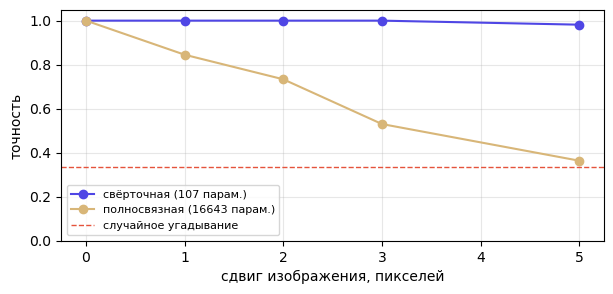

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(shifts, cnn_acc, marker="o", color="#4f46e5", label=f"свёрточная ({cnn_params} парам.)")
ax.plot(shifts, mlp_acc, marker="o", color="#d8b678", label=f"полносвязная ({mlp_params} парам.)")
ax.axhline(1 / 3, color="#e5533c", ls="--", lw=1, label="случайное угадывание")
ax.set_xlabel("сдвиг изображения, пикселей"); ax.set_ylabel("точность")
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()

Читайте по столбцам. У свёрточной сети **107 параметров против 16 643** — в полтораста раз меньше, — и сдвиг она держит полностью до трёх пикселей.

Разделение весов означает, что детектор, найденный в одном углу кадра, работает и в другом. Полносвязная сеть выучила признаки, привязанные к конкретным пикселям, и при сдвиге они оказываются не на своих местах.

Это и есть предположение о данных, встроенное в архитектуру. Никакой оптимизации, никакого дополнительного обучения — просто модель знает о мире то, чего не знает вторая.

**Сломайте:** замените глобальный максимум на пулинг окнами 2×2 с последующим `flatten` — то есть на архитектуру, которую обычно рисуют в учебниках. Точность на сдвиге упадёт примерно до уровня полносвязной сети. Свёртка при этом никуда не денется: пропадёт именно инвариантность.

Затем обучите полносвязную сеть на данных, где фигура уже сдвигается случайно. Догонит ли она свёрточную и сколько ей понадобится параметров?

## 6. Что выучил первый слой

Восемь ядер 3×3 можно просто нарисовать.

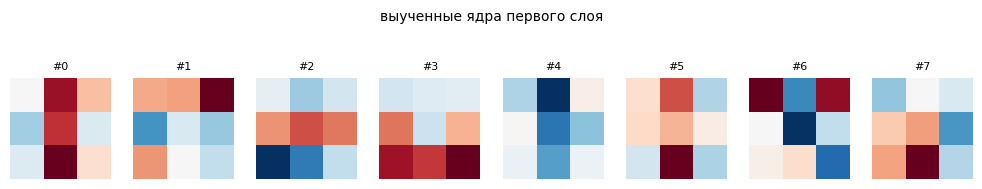

  ядро   похоже на границу по X       по Y
     0                     0.18       0.00
     1                     0.08       0.40
     2                     0.14       0.30
     3                     0.02       0.67
     4                     0.09       0.20
     5                     0.18       0.07
     6                     0.21       0.14
     7                     0.44       0.54


In [10]:
fig, axes = plt.subplots(1, F, figsize=(10, 1.6))
for i, ax in enumerate(axes):
    k = cnn["kernels"][i]
    ax.imshow(k, cmap="RdBu_r", vmin=-np.abs(k).max(), vmax=np.abs(k).max())
    ax.set_title(f"#{i}", fontsize=8); ax.axis("off")
plt.suptitle("выученные ядра первого слоя", y=1.15, fontsize=10)
plt.tight_layout(); plt.show()

# Насколько каждое ядро похоже на детектор границы: сравниваем с Собелем
# по модулю косинуса -- знак не важен, важна ориентация.
def cos(a, b):
    return abs(float(a.ravel() @ b.ravel() / (np.linalg.norm(a) * np.linalg.norm(b))))

print(f"{'ядро':>6} {'похоже на границу по X':>24} {'по Y':>10}")
for i in range(F):
    k = cnn["kernels"][i]
    print(f"{i:>6} {cos(k, sobel_x[0]):>24.2f} {cos(k, sobel_y[0]):>10.2f}")

Ядра никто не проектировал: они появились из градиентного спуска на задаче «отличи полосу от креста». Тем не менее часть из них заметно похожа на операторы границ, которые в компьютерном зрении придумали руками задолго до нейросетей.

**Сломайте:** переобучите сеть с другим зерном и посмотрите на ядра снова. Те же ли детекторы получаются? В том же ли порядке?

## 7. Три модели на одних данных

Свёрточная сеть, полносвязная и бустинг из модуля 6. Правила сравнения — модуля 7.

In [11]:
def best_split(X, y):
    best, parent = (None, None, 0.0), y.var() * len(y)
    for j in range(X.shape[1]):
        for t in np.unique(np.quantile(X[:, j], [0.25, 0.5, 0.75])):
            left = X[:, j] <= t
            nl = int(left.sum())
            if nl < 5 or len(y) - nl < 5:
                continue
            gain = parent - (y[left].var() * nl + y[~left].var() * (len(y) - nl))
            if gain > best[2]:
                best = (j, float(t), float(gain))
    return best

def build_tree(X, y, depth):
    if depth == 0 or len(y) < 10 or y.var() < 1e-12:
        return {"leaf": float(y.mean())}
    j, t, _ = best_split(X, y)
    if j is None:
        return {"leaf": float(y.mean())}
    m = X[:, j] <= t
    return {"f": j, "t": t, "l": build_tree(X[m], y[m], depth - 1),
            "r": build_tree(X[~m], y[~m], depth - 1)}

def predict_tree(tree, X):
    out = np.empty(len(X))
    for i, row in enumerate(X):
        node = tree
        while "leaf" not in node:
            node = node["l"] if row[node["f"]] <= node["t"] else node["r"]
        out[i] = node["leaf"]
    return out

def boost_one_vs_rest(Xf, y, Xt, n_trees=25, lr=0.2, depth=3):
    """Три бинарных бустинга, побеждает наибольший отклик."""
    scores = np.zeros((len(Xt), 3))
    for c in range(3):
        target = (y == c).astype(float)
        base = float(target.mean())
        pred = np.full(len(target), base)
        acc = np.full(len(Xt), base)
        for _ in range(n_trees):
            tree = build_tree(Xf, target - pred, depth)
            pred += lr * predict_tree(tree, Xf)
            acc += lr * predict_tree(tree, Xt)
        scores[:, c] = acc
    return scores.argmax(axis=1)

flat_train = X_train.reshape(len(X_train), -1)
flat_test = X_test.reshape(len(X_test), -1)

boost_pred = boost_one_vs_rest(flat_train, y_train, flat_test)
print(f"{'модель':<26} {'точность на тесте':>18} {'при сдвиге на 2':>17}")

Xs2, ys2 = make_images(600, seed=99, shift=2)
rows = [
    ("свёрточная", accuracy(cnn_forward(cnn, X_test)[0], y_test),
     accuracy(cnn_forward(cnn, Xs2)[0], ys2)),
    ("полносвязная", accuracy(mlp(X_test), y_test), accuracy(mlp(Xs2), ys2)),
    ("бустинг по пикселям", float((boost_pred == y_test).mean()),
     float((boost_one_vs_rest(flat_train, y_train, Xs2.reshape(len(Xs2), -1)) == ys2).mean())),
]
for name, a, b in rows:
    print(f"{name:<26} {a:>18.3f} {b:>17.3f}")

модель                      точность на тесте   при сдвиге на 2


свёрточная                              1.000             1.000
полносвязная                            1.000             0.733
бустинг по пикселям                     0.905             0.402


В модуле 6 бустинг обыгрывал всё на табличных данных, в модуле 8 он обыграл полносвязную сеть. Здесь картина другая, и причина — не в качестве методов, а в том, что у этих данных есть структура.

Бустинг по пикселям видит 256 независимых чисел. Про то, что пиксель 37 и пиксель 38 соседние, ему никто не сказал, и узнать это неоткуда.

Правило из модуля 6 работает в обе стороны: **перед сетью на таблице обучите бустинг, а перед бустингом на изображении — свёрточную сеть.** Метод выбирается под структуру данных, а не по репутации.

## Итог

1. Реализация свёртки проверена на известном ответе: Собель находит границы, ничему не обучаясь.
2. Число параметров свёрточного слоя не зависит от размера картинки: 80 против 100 480 у полносвязного на входе 28×28.
3. Свёртка, пулинг и обратный проход через них приняты gradient check до обучения.
4. При сдвиге изображения свёрточная сеть держит точность, полносвязная сползает — при том что параметров у неё на порядок больше.
5. Первый слой сам выучил ядра, похожие на детекторы границ, придуманные руками задолго до нейросетей.
6. Бустинг, выигравший на таблице, на изображениях проигрывает: у пикселей есть соседство, а он про него не знает.

Дальше — [модуль 10](https://drobyshevdev.github.io/lemma/programme/): последовательности, внимание и трансформер.